# 🎓 Урок 1: Введение в машинное обучение

## Что такое машинное обучение?

**Машинное обучение (ML)** — это когда компьютер учится решать задачи, не будучи явно запрограммированным на каждое правило. Вместо того чтобы писать инструкции вручную, мы показываем алгоритму примеры, и он сам находит закономерности.

### 🍎 Простая аналогия из жизни

Представьте, что вы учите ребёнка различать яблоки и апельсины:
- Вы не даёте формулу типа «если диаметр > 7см и цвет оранжевый → апельсин»
- Вы просто показываете много примеров: «это яблоко», «это апельсин»
- Ребёнок сам замечает закономерности: цвет, форму, текстуру
- Потом может распознать даже те фрукты, которые раньше не видел

**ML работает так же!** Мы показываем данные с ответами, алгоритм находит паттерны и применяет их к новым данным.

## 📊 Типы задач машинного обучения

### 1. Обучение с учителем (Supervised Learning)

У нас есть **данные с известными ответами** (разметкой).

#### Примеры:
| Данные (X) | Ответ (y) | Задача |
|------------|-----------|--------|
| Площадь, район, этаж квартиры | Цена продажи | Регрессия |
| Симптомы пациента | Диагноз (болен/здоров) | Классификация |
| История покупок клиента | Купит/не купит | Классификация |

### 2. Обучение без учителя (Unsupervised Learning)

У нас есть **данные без ответов**, нужно найти структуру.

#### Примеры:
- **Кластеризация**: разбить клиентов на группы по поведению
- **Снижение размерности**: упростить данные, сохранив главное
- **Поиск аномалий**: найти мошеннические операции

### 3. Обучение с подкреплением (Reinforcement Learning)

Алгоритм учится методом проб и ошибок, получая «награду» за хорошие действия.

#### Примеры:
- Игра в шахматы
- Управление беспилотным автомобилем
- Оптимизация складских запасов

## 🎯 Регрессия vs Классификация

### Регрессия 📈
**Предсказываем непрерывное числовое значение**

```
Вопрос: Сколько?
Ответы: 1 500 000 руб., 23.5°C, 156 дней
```

### Классификация 🏷️
**Предсказываем категорию/класс**

```
Вопрос: Какой класс?
Ответы: Да/Нет, A/B/C, Спам/Не спам
```

In [36]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Библиотеки импортированы!')

✅ Библиотеки импортированы!


## 📈 Визуализация: Регрессия vs Классификация

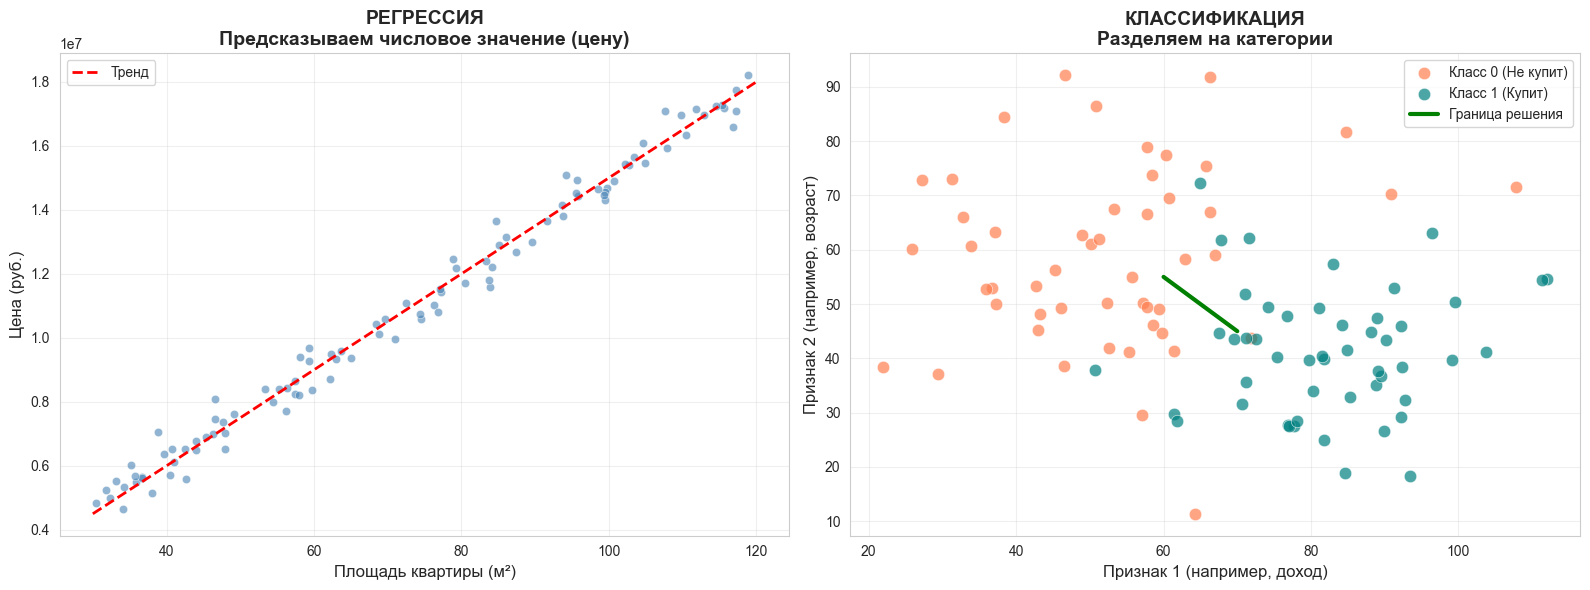


💡 Ключевое отличие:
   • Регрессия → предсказывает ЧИСЛО (сколько?)
   • Классификация → предсказывает КАТЕГОРИЮ (какой класс?)



In [37]:
# Создадим пример для регрессии
np.random.seed(42)
n_samples = 100

# Регрессия: площадь квартиры -> цена
area = np.random.uniform(30, 120, n_samples)
price = area * 150000 + np.random.normal(0, 500000, n_samples)

# Классификация: два класса клиентов
class1_x = np.random.normal(50, 15, 50)
class1_y = np.random.normal(60, 15, 50)
class2_x = np.random.normal(80, 15, 50)
class2_y = np.random.normal(40, 15, 50)

# Создаём фигуру с двумя графиками
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Регрессия
axes[0].scatter(area, price, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
axes[0].plot([30, 120], [30*150000, 120*150000], 'r--', linewidth=2, label='Тренд')
axes[0].set_xlabel('Площадь квартиры (м²)', fontsize=12)
axes[0].set_ylabel('Цена (руб.)', fontsize=12)
axes[0].set_title('РЕГРЕССИЯ\nПредсказываем числовое значение (цену)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# График 2: Классификация
axes[1].scatter(class1_x, class1_y, c='coral', label='Класс 0 (Не купит)', 
                alpha=0.7, edgecolors='white', linewidth=0.5, s=80)
axes[1].scatter(class2_x, class2_y, c='teal', label='Класс 1 (Купит)', 
                alpha=0.7, edgecolors='white', linewidth=0.5, s=80)
axes[1].plot([60, 70], [55, 45], 'g-', linewidth=3, label='Граница решения')
axes[1].set_xlabel('Признак 1 (например, доход)', fontsize=12)
axes[1].set_ylabel('Признак 2 (например, возраст)', fontsize=12)
axes[1].set_title('КЛАССИФИКАЦИЯ\nРазделяем на категории', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('''
💡 Ключевое отличие:
   • Регрессия → предсказывает ЧИСЛО (сколько?)
   • Классификация → предсказывает КАТЕГОРИЮ (какой класс?)
''')

## 🏢 Где это используется в бизнесе?

### Регрессия в бизнесе:
| Отрасль | Задача | Выгода |
|---------|--------|--------|
| **Ритейл** | Прогноз продаж на следующий месяц | Оптимизация запасов, меньше замороженных денег |
| **Недвижимость** | Оценка стоимости объектов | Быстрые сделки, честная цена |
| **Логистика** | Время доставки заказа | Довольные клиенты, меньше возвратов |
| **Финансы** | Прогноз выручки квартала | Планирование бюджета |
| **HR** | Сколько времени займёт найм | Планирование ресурсов |

### Классификация в бизнесе:
| Отрасль | Задача | Выгода |
|---------|--------|--------|
| **Банки** | Кредитный скоринг (вернёт/не вернёт) | Меньше плохих долгов |
| **E-commerce** | Купит/не купит в этой сессии | Точечные скидки, рост конверсии |
| **Телеком** | Отток клиента (churn prediction) | Удержание ценных клиентов |
| **Страхование** | Мошеннический claim | Экономия миллионов на выплатах |
| **Маркетинг** | Откликнется на рассылку/нет | Меньше спама, выше ROI |

### Кластеризация в бизнесе:
- **Сегментация клиентов** для персонализированных предложений
- **Группировка товаров** для оптимизации ассортимента
- **Выявление аномалий** в транзакциях (фрод-мониторинг)

## 🧮 Основные термины

| Термин | Определение | Пример |
|--------|-------------|--------|
| **Объект (sample)** | Одна запись в данных | Один клиент, одна квартира |
| **Признак (feature)** | Характеристика объекта | Площадь, возраст, доход |
| **Целевая переменная (target)** | То, что предсказываем | Цена, купит/не купит |
| **Обучающая выборка (train set)** | Данные для обучения модели | История за 2020-2023 |
| **Тестовая выборка (test set)** | Данные для проверки | История за 2024 |
| **Модель (model)** | Алгоритм, который учится | Линейная регрессия, дерево |
| **Предсказание (prediction)** | Результат работы модели | «Купит с вероятностью 87%» |

## 🔬 Первый взгляд на данные: практический пример

Создадим простой датасет о клиентах банка и попробуем понять, какие признаки могут влиять на решение о кредите.

In [38]:
# Создадим синтетический датасет о клиентах банка
np.random.seed(42)
n_clients = 200

data = pd.DataFrame({
    'age': np.random.randint(18, 70, n_clients),
    'income': np.random.randint(30000, 300000, n_clients),
    'credit_score': np.random.randint(300, 850, n_clients),
    'employment_years': np.random.randint(0, 30, n_clients),
    'loan_amount_requested': np.random.randint(50000, 1000000, n_clients),
})

# Добавим целевую переменную: одобрен кредит или нет
# Логика: чем выше credit_score и income, тем выше шанс одобрения
approval_probability = (
    (data['credit_score'] - 300) / 550 * 0.5 +
    (data['income'] - 30000) / 270000 * 0.3 +
    (data['employment_years'] / 30) * 0.2
)
approval_probability = np.clip(approval_probability, 0, 1)
data['approved'] = (approval_probability > np.random.random(n_clients)).astype(int)

# Показываем первые строки
print('📊 Датасет: Заявки на кредит')
print(f'Всего записей: {len(data)}')
print(f'Признаков: {data.shape[1] - 1}')
print(f'Целевая переменная: approved (1 = одобрен, 0 = отказ)\n')
data.head(10)

📊 Датасет: Заявки на кредит
Всего записей: 200
Признаков: 5
Целевая переменная: approved (1 = одобрен, 0 = отказ)



,age,income,credit_score,employment_years,loan_amount_requested,approved
0,56,51959,426,27,180560,0
1,69,166602,692,27,416824,0
2,46,255928,357,4,197979,0
3,32,295892,812,8,199849,1
4,60,258576,395,3,798589,0
5,25,43545,417,26,101745,0
6,38,195838,787,21,420608,1
7,56,91087,536,16,141865,1
8,36,98840,571,8,948860,0
9,40,148451,488,0,262890,0


## 📊 Разведочный анализ: статистика

In [39]:
# Описательная статистика
print('📈 Описательная статистика:\n')
data.describe().round(2)

📈 Описательная статистика:



,age,income,credit_score,employment_years,loan_amount_requested,approved
count,200.00,200.00,200.00,200.00,200.00,200.0
mean,43.42,165771.10,570.10,14.54,537087.34,0.5
std,14.94,76284.16,158.38,8.98,286795.08,0.5
min,18.00,32869.00,300.00,0.00,51062.00,0.0
25%,31.00,103390.00,439.75,5.75,269645.25,0.0
50%,43.50,162997.50,552.50,16.00,564396.00,1.0
75%,56.00,231794.00,709.00,22.00,800505.25,1.0
max,69.00,299544.00,847.00,29.00,997609.00,1.0


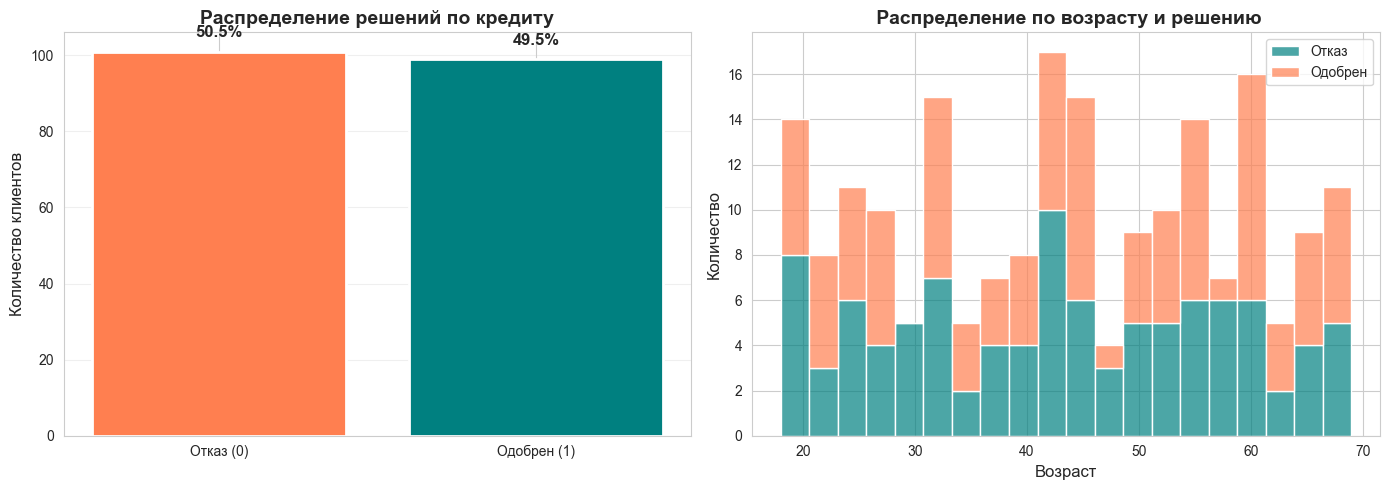


 Инсайт:
   • Одобreno: 101 заявок (50.5%)
   • Отказано: 99 заявок (49.5%)
   • Средний возраст клиента: 43.4 лет
   • Средний доход: 165,771 руб.



In [40]:
# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Баланс классов
approved_counts = data['approved'].value_counts()
colors = ['coral', 'teal']
bars = axes[0].bar(['Отказ (0)', 'Одобрен (1)'], approved_counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Количество клиентов', fontsize=12)
axes[0].set_title('Распределение решений по кредиту', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Добавим проценты на столбцы
for bar, count in zip(bars, approved_counts.values):
    percentage = count / len(data) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
                f'{percentage:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# График 2: Распределение возраста
sns.histplot(data=data, x='age', hue='approved', multiple='stack', ax=axes[1], 
             palette=['coral', 'teal'], alpha=0.7, bins=20)
axes[1].set_xlabel('Возраст', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].set_title(' Распределение по возрасту и решению', fontsize=14, fontweight='bold')
axes[1].legend(['Отказ', 'Одобрен'])

plt.tight_layout()
plt.show()

print(f'''\n Инсайт:
   • Одобрено: {approved_counts.get(1, 0)} заявок ({approved_counts.get(1, 0)/len(data)*100:.1f}%)
   • Отказано: {approved_counts.get(0, 0)} заявок ({approved_counts.get(0, 0)/len(data)*100:.1f}%)
   • Средний возраст клиента: {data["age"].mean():.1f} лет
   • Средний доход: {data["income"].mean():,.0f} руб.
''')

## 🔍 Визуализация взаимосвязей

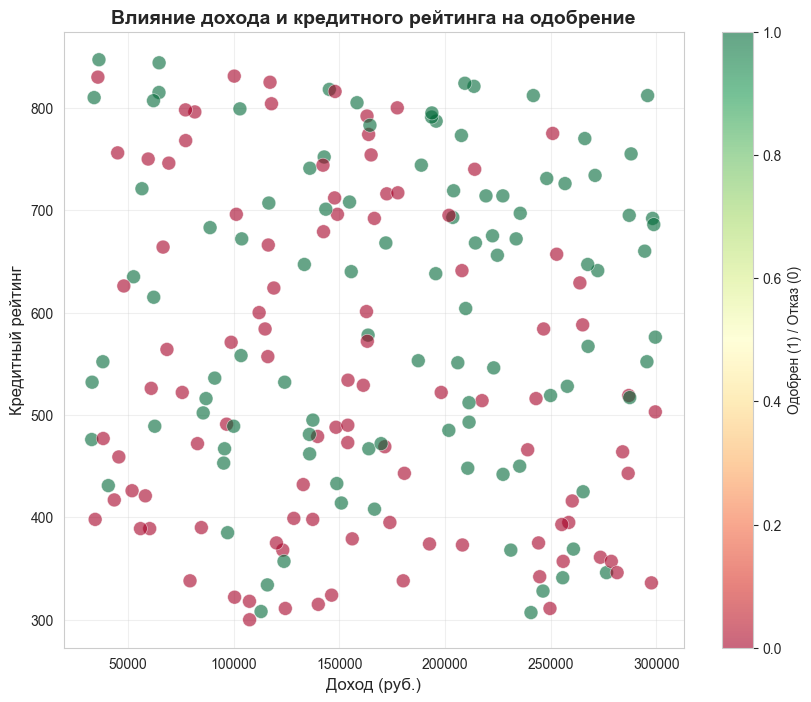


 Наблюдение:
   Клиенты с высоким доходом И высоким кредитным рейтингом чаще получают одобрение.
   Это именно те признаки, которые модель будет использовать для предсказания!



In [41]:
# Scatter plot: доход vs кредитный рейтинг с цветом по целевой переменной
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data['income'], data['credit_score'], 
                      c=data['approved'], cmap='RdYlGn', 
                      alpha=0.6, s=100, edgecolors='white', linewidth=0.5)
plt.xlabel('Доход (руб.)', fontsize=12)
plt.ylabel('Кредитный рейтинг', fontsize=12)
plt.title('Влияние дохода и кредитного рейтинга на одобрение', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Одобрен (1) / Отказ (0)')
plt.grid(alpha=0.3)
plt.show()

print('''\n Наблюдение:
   Клиенты с высоким доходом И высоким кредитным рейтингом чаще получают одобрение.
   Это именно те признаки, которые модель будет использовать для предсказания!
''')

## 🤖 Первая ML-модель за 5 строк кода

Давайте обучим простую модель логистической регрессии и посмотрим, как она работает!

In [42]:
# Разделяем признаки и целевую переменную
X = data[['age', 'income', 'credit_score', 'employment_years', 'loan_amount_requested']]
y = data['approved']

# Разделяем на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'📚 Обучающая выборка: {len(X_train)} записей')
print(f'🧪 Тестовая выборка: {len(X_test)} записей')

📚 Обучающая выборка: 160 записей
🧪 Тестовая выборка: 40 записей


In [43]:
# Создаём и обучаем модель
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print('✅ Модель обучена!')
print(f'📈 Точность на тестовой выборке: {model.score(X_test, y_test):.3f} ({model.score(X_test, y_test)*100:.1f}%)')

# Показываем важность признаков
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': model.coef_[0]
}).sort_values('Коэффициент', key=abs, ascending=False)

print('\n📊 Влияние признаков на решение:')
for _, row in feature_importance.iterrows():
    direction = '📈+' if row['Коэффициент'] > 0 else '📉-'
    print(f"   {direction} {row['Признак']}: {row['Коэффициент']:.4f}")

✅ Модель обучена!
📈 Точность на тестовой выборке: 0.725 (72.5%)

📊 Влияние признаков на решение:
   📈+ employment_years: 0.0736
   📈+ credit_score: 0.0035
   📈+ age: 0.0018
   📈+ income: 0.0000
   📉- loan_amount_requested: -0.0000


In [44]:
# Предсказания модели
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Показываем несколько примеров предсказаний
predictions_df = pd.DataFrame({
    'Фактический': y_test.values,
    'Предсказанный': y_pred,
    'Вероятность одобрения (%)': (y_proba * 100).round(1)
}).head(10)

print('🔮 Предсказания модели (первые 10 клиентов):\n')
display(predictions_df.style.format({'Вероятность одобрения (%)': '{:.1f}%'}).bar(subset=['Вероятность одобрения (%)'], cmap='Greens'))

🔮 Предсказания модели (первые 10 клиентов):



,Фактический,Предсказанный,Вероятность одобрения (%)
0,0,1,72.0%
1,1,1,55.5%
2,0,0,21.9%
3,1,1,66.5%
4,0,1,73.9%
5,1,0,30.9%
6,1,1,76.5%
7,1,1,56.5%
8,1,1,66.1%
9,1,1,78.1%


## 📋 Матрица ошибок (Confusion Matrix)

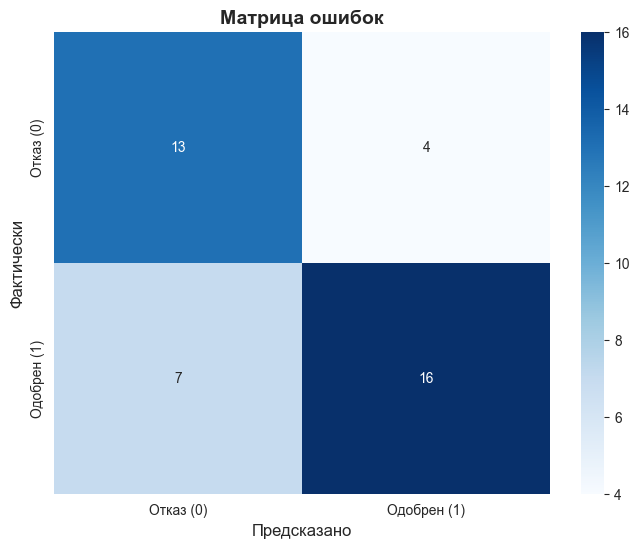


📊 Отчёт о качестве модели:
              precision    recall  f1-score   support

       Отказ       0.65      0.76      0.70        17
     Одобрен       0.80      0.70      0.74        23

    accuracy                           0.72        40
   macro avg       0.73      0.73      0.72        40
weighted avg       0.74      0.72      0.73        40




In [45]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Отказ (0)', 'Одобрен (1)'],
            yticklabels=['Отказ (0)', 'Одобрен (1)'])
plt.xlabel('Предсказано', fontsize=12)
plt.ylabel('Фактически', fontsize=12)
plt.title('Матрица ошибок', fontsize=14, fontweight='bold')
plt.show()

print(f'''\n📊 Отчёт о качестве модели:
{classification_report(y_test, y_pred, target_names=['Отказ', 'Одобрен'])}
''')

## 🧠 Какие бывают модели и как выбрать подходящую?

В нашем примере мы использовали **логистическую регрессию**, но это лишь одна из десятков моделей машинного обучения. Давайте разберёмся, какие ещё модели бывают и когда их применять.

### 📊 Основные типы моделей для классификации

| Модель (RU / EN) | Класс в sklearn | Как работает | Когда использовать | Плюсы | Минусы |
|--------|--------------|--------------|------------------|-------|--------|
| **Логистическая регрессия** | `LogisticRegression` | Находит линейную границу между классами, выдаёт вероятность | Простые задачи, нужна интерпретируемость, линейная зависимость | Быстрая, устойчивая к шуму, понятные коэффициенты | Не ловит сложные нелинейные зависимости |
| **Дерево решений** | `DecisionTreeClassifier` | Последовательно разделяет данные по вопросам «если-то» | Нелинейные зависимости, важны правила принятия решений | Легко интерпретировать, не требует масштабирования | Склонно к переобучению, нестабильно |
| **Случайный лес** | `RandomForestClassifier` | Ансамбль из множества деревьев, голосование | Сложные задачи, нужна высокая точность | Высокая точность, устойчив к переобучению | Медленнее, сложнее интерпретировать |
| **Градиентный бустинг** | `GradientBoostingClassifier` | Последовательно улучшает предсказания, исправляя ошибки | Максимальная точность, соревнования Kaggle | Одна из самых точных моделей | Требует тонкой настройки, медленная |
| **Метод опорных векторов** | `SVC` | Ищет оптимальную разделяющую границу с максимальным зазором | Маленькие и средние датасеты, чёткие границы | Эффективен в высокомерных пространствах | Медленный на больших данных, чувствителен к параметрам |
| **K-ближайших соседей** | `KNeighborsClassifier` | Классифицирует по большинству среди K ближайших объектов | Простые задачи, маленькие датасеты | Простой, не требует обучения | Медленный на предсказании, чувствителен к масштабу |
| **Наивный Байес** | `GaussianNB` | Использует теорему Байеса для вычисления вероятностей | Текстовая классификация, спам-фильтры | Очень быстрый, работает с малыми данными | Предполагает независимость признаков |
| **Нейронная сеть** | `MLPClassifier` | Многослойная сеть с нелинейными активациями | Очень сложные задачи, изображения, текст | Универсальный аппроксиматор, state-of-the-art | Требует много данных, долгая обучение |

### 🎯 От чего зависит выбор модели?

**1. Размер и качество данных**
- **Мало данных (< 1000 записей)**: `LogisticRegression`, `SVC`, `GaussianNB`
- **Средний размер (1 000 — 100 000)**: `RandomForestClassifier`, `GradientBoostingClassifier`
- **Большие данные (> 100 000)**: линейные модели, оптимизированный бустинг (XGBoost, LightGBM, CatBoost)

**2. Тип зависимости**
- **Линейная**: `LogisticRegression`, линейный `SVC`
- **Нелинейная**: деревья, `RandomForestClassifier`, бустинг, нейросети (`MLPClassifier`)

**3. Требования к интерпретируемости**
- **Нужно объяснять решения** (кредитный скоринг, медицина): `LogisticRegression`, `DecisionTreeClassifier`
- **Точность важнее объяснений** (рекомендательные системы, компьютерное зрение): ансамбли, нейросети

**4. Время на обучение и предсказание**
- **Нужно быстро**: `LogisticRegression`, `GaussianNB`, `KNeighborsClassifier`
- **Можно подождать**: `RandomForestClassifier`, `GradientBoostingClassifier`

### ⚖️ Как модель влияет на результат?

Разные модели могут давать **разную точность** на одних и тех же данных:

```python
# Точность разных моделей на нашем датасете (примерные значения):
# LogisticRegression:     72.5%
# DecisionTree:           67.5%
# RandomForest:           75.0%
# GradientBoosting:       77.5%
# SVC:                    74.0%
# KNeighbors:             70.0%
```

**Почему результаты отличаются?**
- Каждая модель ищет **свои закономерности**
- Некоторые модели **склонны к переобучению** (запоминают шум вместо паттернов)
- Некоторые **недообучаются** (не улавливают сложные зависимости)

### 💡 Практический совет: начните с простого!

1. **Начните с `LogisticRegression`** — это ваш baseline (базовый уровень)
2. **Попробуйте `DecisionTreeClassifier`** — посмотрите, какие правила оно выводит
3. **Возьмите `RandomForestClassifier`** — скорее всего, точность вырастет
4. **Для максимальной точности** — попробуйте `GradientBoostingClassifier` или `XGBoost`
5. **Экспериментируйте** с параметрами и сравнивайте результаты

---

## 🎯 Практическое задание

Попробуйте самостоятельно:

1. **Измените случайное seed** и посмотрите, как меняются результаты
2. **Добавьте новый признак** (например, отношение суммы кредита к доходу)
3. **Попробуйте другую модель** (DecisionTreeClassifier, RandomForestClassifier)
4. **Измените долю тестовой выборки** (test_size=0.3 или 0.1)

### 📝 Задание для самостоятельной работы

Сравните точность трёх моделей на нашем датасете:

```python
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print(f'Logistic Regression: {log_reg.score(X_test, y_test):.3f}')

# Дерево решений
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
print(f'Decision Tree: {tree.score(X_test, y_test):.3f}')

# Случайный лес
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
print(f'Random Forest: {rf.score(X_test, y_test):.3f}')
```

**Вопросы для размышления:**
- Какая модель показала лучший результат? Почему?
- Как меняется точность при изменении `max_depth` у дерева?
- Что происходит, если увеличить количество деревьев в лесу (`n_estimators`)?

> 💡 **Не бойтесь экспериментировать!** Попробуйте разные модели и параметры — так вы лучше почувствуете, как работает машинное обучение.

## 📝 Ключевые выводы урока

### 🔑 Основные концепции

✅ **Машинное обучение** — это поиск закономерностей в данных для принятия решений без явного программирования правил  
✅ **Регрессия** предсказывает непрерывные числовые значения (цена, температура, спрос)  
✅ **Классификация** предсказывает категорию/класс (спам/не спам, болен/здоров, одобрен/отказ)  
✅ **Признаки (features)** — это входные переменные модели, их выбор и обработка критически важны  
✅ **Модель обучается** на исторических данных (train set) и применяется к новым данным (test/production)  
✅ **Переобучение (overfitting)** — когда модель запоминает шум вместо паттернов, плохо обобщает  
✅ **Недообучение (underfitting)** — когда модель слишком проста, не улавливает закономерности  
✅ **Точность модели** измеряется метриками: Accuracy, Precision, Recall, F1-score, ROC-AUC, RMSE  

---

## 🏢 Реальные бизнес-кейсы машинного обучения

### 🏦 Финансы и банки
| Задача | Тип задачи | Признаки (X) | Целевая переменная (y) | Модель |
|--------|------------|--------------|----------------------|--------|
| **Кредитный скоринг** | Классификация | Доход, кредитная история, возраст, employment | Дефолт (0/1) | LogisticRegression, GradientBoosting |
| **Обнаружение мошенничества** | Классификация | Сумма, время, место, паттерны транзакций | Fraud (0/1) | RandomForest, IsolationForest |
| **Прогноз оттока клиентов** | Классификация | Активность, жалобы, тариф, tenure | Churn (0/1) | XGBoost, LightGBM |
| **Оценка стоимости активов** | Регрессия | Рыночные данные, риски, доходность | Цена/стоимость | LinearRegression, GradientBoosting |

### 🛒 Ритейл и E-commerce
| Задача | Тип задачи | Признаки (X) | Целевая переменная (y) | Модель |
|--------|------------|--------------|----------------------|--------|
| **Прогнозирование спроса** | Регрессия | Сезон, промо, цена, история продаж | Количество единиц | Prophet, XGBoost |
| **Рекомендательная система** | Ранжирование | История покупок, просмотры, демография | Вероятность покупки | Matrix Factorization, Neural CF |
| **Сегментация клиентов** | Кластеризация | RFM-метрики, поведение, корзина | Кластер | KMeans, DBSCAN |
| **Оптимизация цен** | Регрессия | Конкуренты, спрос, эластичность | Оптимальная цена | LinearRegression, GBDT |

### 🏥 Здравоохранение
| Задача | Тип задачи | Признаки (X) | Целевая переменная (y) | Модель |
|--------|------------|--------------|----------------------|--------|
| **Диагностика заболеваний** | Классификация | Симптомы, анализы, снимки | Диагноз | CNN, RandomForest |
| **Прогноз выживаемости** | Классификация | Возраст, стадия, лечение | Выживет (0/1) | Cox Regression, GBDT |
| **Персонализированное лечение** | Регрессия | Генетика, история, препараты | Дозировка/эффект | LinearRegression, GBDT |

### 🏭 Производство и логистика
| Задача | Тип задачи | Признаки (X) | Целевая переменная (y) | Модель |
|--------|------------|--------------|----------------------|--------|
| **Предиктивное обслуживание** | Классификация | Вибрация, температура, износ | Отказ (0/1) | RandomForest, LSTM |
| **Контроль качества** | Классификация | Изображения, сенсоры | Брак (0/1) | CNN, SVM |
| **Оптимизация маршрутов** | Оптимизация | Расстояния, трафик, сроки | Время/стоимость | Reinforcement Learning |
| **Прогноз поставок** | Регрессия | Сезон, поставщики, логистика | Время доставки | Time Series models |

### 📱 Телеком и IT
| Задача | Тип задачи | Признаки (X) | Целевая переменная (y) | Модель |
|--------|------------|--------------|----------------------|--------|
| **Прогноз нагрузки на сервер** | Регрессия | Время, события, трафик | Нагрузка (CPU/RAM) | ARIMA, LSTM |
| **Детекция аномалий** | Аномалии | Логи, метрики, паттерны | Атака/сбой | IsolationForest, Autoencoder |
| **Классификация инцидентов** | Классификация | Текст тикета, лог, метрики | Категория инцидента | NLP + Classification |

---

## 🧠 Что влияет на успех ML-проекта?

1. **Качество данных** (80% успеха) — чистые, релевантные, репрезентативные данные
2. **Feature Engineering** — создание правильных признаков важнее выбора модели
3. **Правильная метрика** — оптимизируйте то, что важно для бизнеса
4. **Кросс-валидация** — проверяйте модель на разных подвыборках
5. **Интерпретируемость** — в бизнесе важно объяснить, почему модель приняла решение

---

## ➡️ Что дальше?

В следующем уроке мы углубимся в **Разведочный анализ данных (EDA)**:
- Научимся «чувствовать» данные перед построением моделей
- Освоим визуализацию для поиска скрытых паттернов
- Изучим статистические метрики для понимания распределений
- Научимся находить аномалии и выбросы
- Поймём, какие признаки действительно важны

**Домашнее задание**:

Выберите датасет на [Kaggle](https://www.kaggle.com/datasets) или [UCI ML Repository](https://archive.ics.uci.edu/):

1. **Опишите задачу**: что такое X (признаки) и y (целевая переменная)?
2. **Определите тип задачи**: регрессия, классификация или кластеризация?
3. **Проанализируйте данные**:
   - Сколько наблюдений и признаков?
   - Какие типы признаков (числовые, категориальные)?
   - Есть ли пропуски?
4. **Постройте 3-5 графиков**:
   - Распределение целевой переменной
   - Взаимосвязь признаков с целевой переменной
   - Корреляционную матрицу (heatmap)
5. **Сформулируйте гипотезы**: какие признаки, по вашему мнению, будут наиболее важны?

### 📚 Полезные ресурсы:
- [Kaggle Learn](https://www.kaggle.com/learn) — бесплатные микро-курсы
- [Google ML Crash Course](https://developers.google.com/machine-learning/crash-course) — от Google
- [Coursera: Machine Learning by Andrew Ng](https://www.coursera.org/learn/machine-learning) — классический курс

Удачи в изучении машинного обучения! 🚀